[nltk_data] Downloading package stopwords to C:\Users\NITRO
[nltk_data]     V\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- Model Evaluation ---
Accuracy: 0.8626

Classification Report:
               precision    recall  f1-score   support

    negative       0.87      0.85      0.86      4961
    positive       0.86      0.87      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



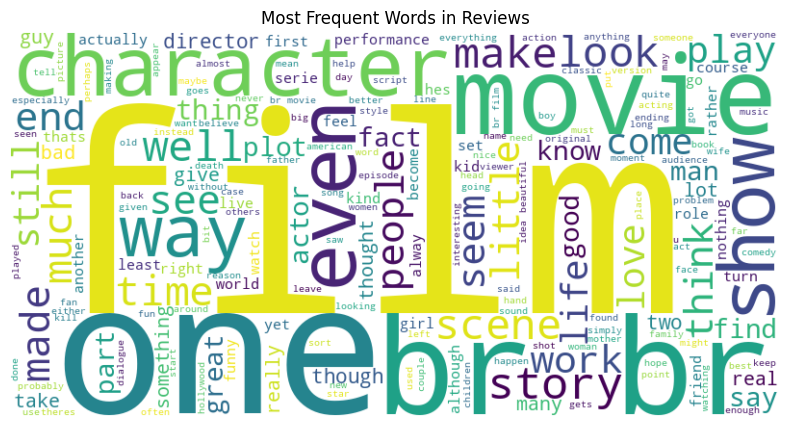

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# 1. DATA COLLECTION (Using a sample dataset)
# Replace this block with: df = pd.read_csv('your_actual_reviews.csv')
df=pd.read_csv('IMDB-Dataset.csv')

# 2. DATA PREPROCESSING
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    text = " ".join([word for word in text.split() if word not in stop_words]) # Remove stop words
    return text

df['cleaned_review'] = df['review'].apply(clean_text)

# 3. FEATURE EXTRACTION (TF-IDF)
X = df['cleaned_review']
y = df['sentiment']

# Split into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 4. MODEL SELECTION & TRAINING (Logistic Regression)
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# 5. MODEL EVALUATION
y_pred = model.predict(X_test_tfidf)
print("--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. WORD CLOUD VISUALIZATION (Bonus)
all_words = ' '.join(df['cleaned_review'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Reviews")
plt.show()